# 03 — Fully Sensorless Control (observer closes the loop)

**Stage 3** of the sensorless-drive build. Same plant, same current-controller structure and
gains, same αβ Structure-B observer + PLL as notebooks 01/02 — but now the controller's
feedback is **θ̂, ω̂ from the observer/PLL**, not the plant's real θr/ωmech. This is the
fully sensorless configuration.

The angle-mismatch physics from `THEORY.md` §2.4 is modeled explicitly:
- the controller only ever sees currents expressed through its **own estimated** θ̂ (`Park(θ̂)`
  applied to the plant's real, physically-measurable α/β currents),
- the voltage it commands is synthesized via **inverse Park at θ̂** (`v_α,v_β`) — that's what a
  real inverter would actually put out, having no access to the real angle,
- that same physical `v_α,v_β` is what both (a) drives the observer, and (b) — after being
  re-expressed into the **real** machine's own dq frame via `Park(θr)` — actually drives the
  plant.

Skipping that re-projection would silently hide the entire point of this notebook (angle
error would never show up as anything). Real θr/ωmech are kept only as ground truth for
plotting/error metrics — the control loop itself never reads them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pmsm_common as pc

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

p = pc.make_params()
print(f"Current loop:  Kp_d={p.Kp_d:.3f} Ki_d={p.Ki_d:.1f}  Kp_q={p.Kp_q:.3f} Ki_q={p.Ki_q:.1f}")
print(f"Observer: Ki_P={p.Ki_P:.1f} Ki_I={p.Ki_I:.3e} Ke_P={p.Ke_P:.1f} Ke_I={p.Ke_I:.3e}  "
      f"PLL: Kp_pll={p.Kp_pll:.1f} Ki_pll={p.Ki_pll:.3e}")
print(f"Vmax={p.Vmax} V")

Current loop:  Kp_d=9.000 Ki_d=900.0  Kp_q=8.800 Ki_q=900.0
Observer: Ki_P=239898.9 Ki_I=1.280e+10 Ke_P=1139200.0 Ke_I=9.114e+10  PLL: Kp_pll=1131.2 Ki_pll=6.400e+05
Vmax=600.0 V


## Right-hand side — controller driven by θ̂/ω̂, plant driven by the real angle

Same 14-state layout as notebook 02. The differences from notebook 02's `rhs_nb2` are
exactly the angle-mismatch handling described above (marked `<<<` below); the observer/PLL
equations themselves (Structure B + PLL) are unchanged.

In [2]:
def rhs_nb3(t, x, p):
    (isd, isq, omega_mech, theta_r, xi_d, xi_q,
     ia_hat, ib_hat, ea_hat, eb_hat, z_a, z_b, theta_pll, omega_pll) = x

    omega_r_real = p.p * omega_mech       # real electrical speed -- plant only, controller never sees it
    omega_r_hat = omega_pll               # <<< estimated electrical speed, used by the controller
    theta_hat = theta_pll                 # <<< estimated angle, used by the controller

    # --- plant's real alpha-beta currents: physically measurable, independent of any frame belief ---
    i_alpha, i_beta = pc.dq_to_alphabeta(isd, isq, theta_r)

    # --- controller's OWN view of the currents, via its estimated angle <<< ---
    isd_hat, isq_hat = pc.alphabeta_to_dq(i_alpha, i_beta, theta_hat)

    # --- current errors against ESTIMATED currents <<< ---
    err_d = p.isd_ref - isd_hat
    err_q = p.isq_ref - isq_hat

    # --- EMF feedforward using ESTIMATED speed/currents <<< ---
    ff_d = -omega_r_hat * p.Lq * isq_hat
    ff_q = omega_r_hat * p.Ld * isd_hat + omega_r_hat * p.psi_m_pi

    usd_unsat = p.Kp_d * err_d + xi_d + ff_d
    usq_unsat = p.Kp_q * err_q + xi_q + ff_q
    usd_cmd, usq_cmd, _sat = pc.saturate_voltage(usd_unsat, usq_unsat, p.Vmax)
    dxi_d = p.Ki_d * err_d + pc.antiwindup_term(usd_unsat, usd_cmd, p.Kp_d)
    dxi_q = p.Ki_q * err_q + pc.antiwindup_term(usq_unsat, usq_cmd, p.Kp_q)

    # --- physical voltage vector as an inverter driven by theta_hat would actually synthesize <<< ---
    v_alpha, v_beta = pc.dq_to_alphabeta(usd_cmd, usq_cmd, theta_hat)

    # --- re-expressed into the REAL machine's own dq frame -- this is what actually drives the plant <<< ---
    usd_real, usq_real = pc.alphabeta_to_dq(v_alpha, v_beta, theta_r)

    # --- plant electrical equations (real theta_r/omega_r, real applied voltage) ---
    disd = (usd_real - p.Rs * isd + omega_r_real * p.Lq * isq) / p.Ld
    disq = (usq_real - p.Rs * isq - omega_r_real * p.Ld * isd - omega_r_real * p.psi_m_pi) / p.Lq

    Te = p.p * p.psi_m_pi * isq + p.p * (p.Ld - p.Lq) * isd * isq
    T_load = p.k_fan * omega_mech * abs(omega_mech)
    domega_mech = (Te - T_load - p.B * omega_mech) / p.J
    dtheta_r = omega_r_real

    # --- Structure-B observer, fed by the REAL i_alpha,i_beta and the ACTUALLY-commanded v_alpha,v_beta ---
    di_a = i_alpha - ia_hat
    di_b = i_beta - ib_hat
    dia_hat = (-(p.Rs / p.L_obs) * ia_hat - (1 / p.L_obs) * ea_hat + (1 / p.L_obs) * v_alpha
               + p.Ki_P * di_a + p.Ki_I * z_a)
    dib_hat = (-(p.Rs / p.L_obs) * ib_hat - (1 / p.L_obs) * eb_hat + (1 / p.L_obs) * v_beta
               + p.Ki_P * di_b + p.Ki_I * z_b)
    dea_hat = -(p.Ke_P * di_a + p.Ke_I * z_a)
    deb_hat = -(p.Ke_P * di_b + p.Ke_I * z_b)
    dz_a = di_a
    dz_b = di_b

    theta_raw = np.arctan2(-ea_hat, eb_hat)
    phase_err = np.sin(theta_raw - theta_pll)
    dtheta_pll = omega_pll + p.Kp_pll * phase_err
    domega_pll = p.Ki_pll * phase_err

    return [disd, disq, domega_mech, dtheta_r, dxi_d, dxi_q,
            dia_hat, dib_hat, dea_hat, deb_hat, dz_a, dz_b, dtheta_pll, domega_pll]

## Torque-command schedule simulation (same schedule as notebooks 01/02)

Given the θ+π lock risk during the `-20` N·m (negative-speed) level flagged in notebook 02,
that level is expected to **not converge**: the controller ends up chasing an intermittently
sign-flipped current estimate, which keeps the drive oscillating chaotically in a small band
around zero speed rather than settling. That chaotic θ_err also makes the adaptive integrator
work much harder (many tiny steps) than anywhere else in this build — confirmed by profiling
(`_diag_nb3.py`, not part of the deliverable): tens to hundreds of ms wall-clock per 5 ms of
simulated time on that level alone, vs. a few ms/5ms elsewhere, and it does not visibly let up
within at least a couple of simulated seconds. Rather than chase a simulated-time budget that
turned out to be an unreliable predictor of wall-clock cost in a chaotic regime, this call
uses `pmsm_common`'s **wall-clock safety valve** (`max_wall_time_per_level`) as the real
cutoff, plus a slightly looser integrator tolerance (still far tighter than needed for the
currents/speeds involved) to keep the fine chaotic structure from being resolved more
precisely than it needs to be for the qualitative point being made here.
**This cell is capped at ~90 s for the pathological level and takes roughly 2 minutes total.**

In [3]:
torque_levels = [0, 10, 30, 50, 70, 10, 70, -20, 50]

x0 = np.zeros(14)
p = pc.make_params()

import time
t0 = time.time()
result = pc.simulate_schedule(rhs_nb3, x0, p, torque_levels, max_time=2.0,
                               rtol=1e-6, atol=1e-8, max_wall_time_per_level=90.0)
print(f"simulated {result.t[-1]:.3f} s of drive time in {time.time()-t0:.1f} s wall-clock, "
      f"{result.t.size} samples")
print("converged per level:", result.converged_flags)

  [warning] level Tref=70 N*m did not converge within 2.0s of simulated time (last |domega/dt|=0.000, |diq|=0.0977)


  [warning] level Tref=70 N*m did not converge within 2.0s of simulated time (last |domega/dt|=0.000, |diq|=0.0977)


  [warning] level Tref=-20 N*m did not converge within 2.0s of simulated time (last |domega/dt|=-165.612, |diq|=34.3924)


  [warning] level Tref=50 N*m did not converge within 2.0s of simulated time (last |domega/dt|=-0.000, |diq|=154.0073)
simulated 11.215 s of drive time in 100.4 s wall-clock, 1274494 samples
converged per level: [True, True, True, True, False, True, False, False, False]


## Results — plant, driven fully sensorless

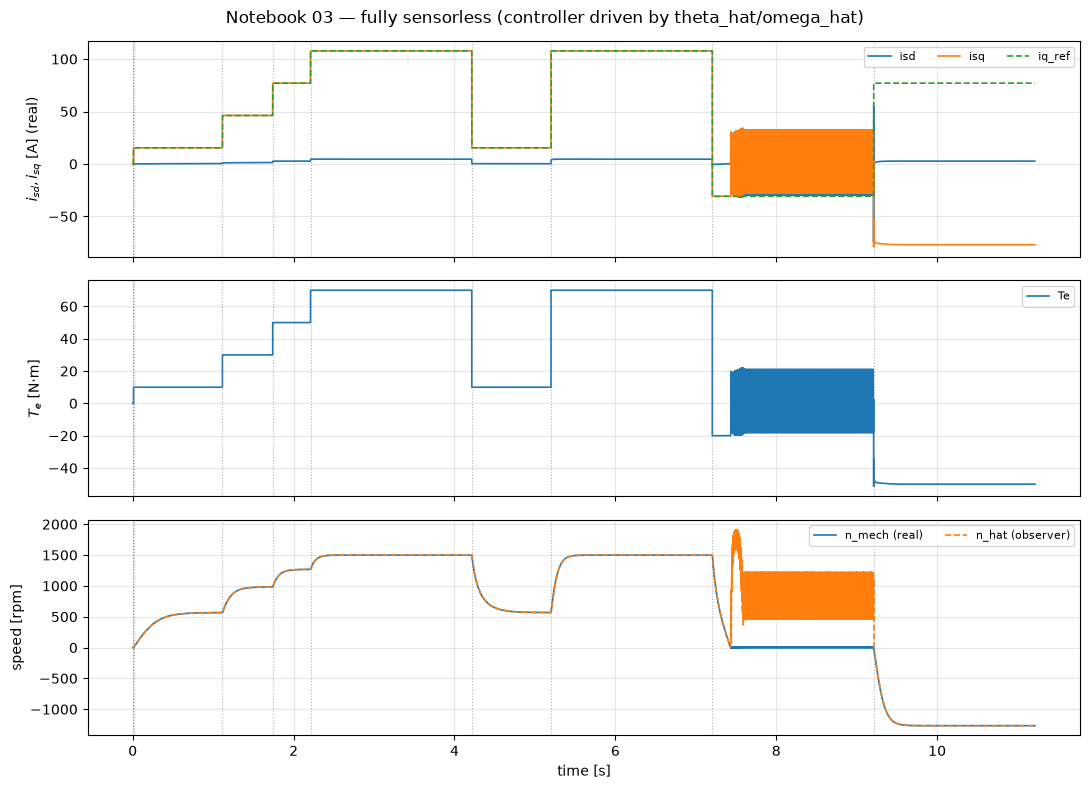

In [4]:
t = result.t
X = result.X
isd, isq, omega_mech, theta_r = X[0], X[1], X[2], X[3]
theta_pll, omega_pll = X[12], X[13]

level_times = result.level_times
level_values = result.level_values
iq_ref_t = np.piecewise(t, [t >= lt for lt in level_times],
                         [v / (p.p * p.psi_m_pi) for v in level_values])
Te = p.p * p.psi_m_pi * isq + p.p * (p.Ld - p.Lq) * isd * isq
n_mech = omega_mech * 60 / (2 * np.pi)
n_hat = (omega_pll / p.p) * 60 / (2 * np.pi)

fig, axes = pc.plot_traces(
    t,
    {
        r"$i_{sd},i_{sq}$ [A] (real)": [("isd", isd), ("isq", isq), ("iq_ref", iq_ref_t, "--")],
        r"$T_e$ [N·m]": [("Te", Te)],
        "speed [rpm]": [("n_mech (real)", n_mech), ("n_hat (observer)", n_hat, "--")],
    },
    level_times=level_times,
    title="Notebook 03 — fully sensorless (controller driven by theta_hat/omega_hat)",
)

## Estimation error and voltage-saturation check

unsaturated command magnitude: max=1116.9 V, Vmax=600.0 V, fraction of samples saturated=0.0015%


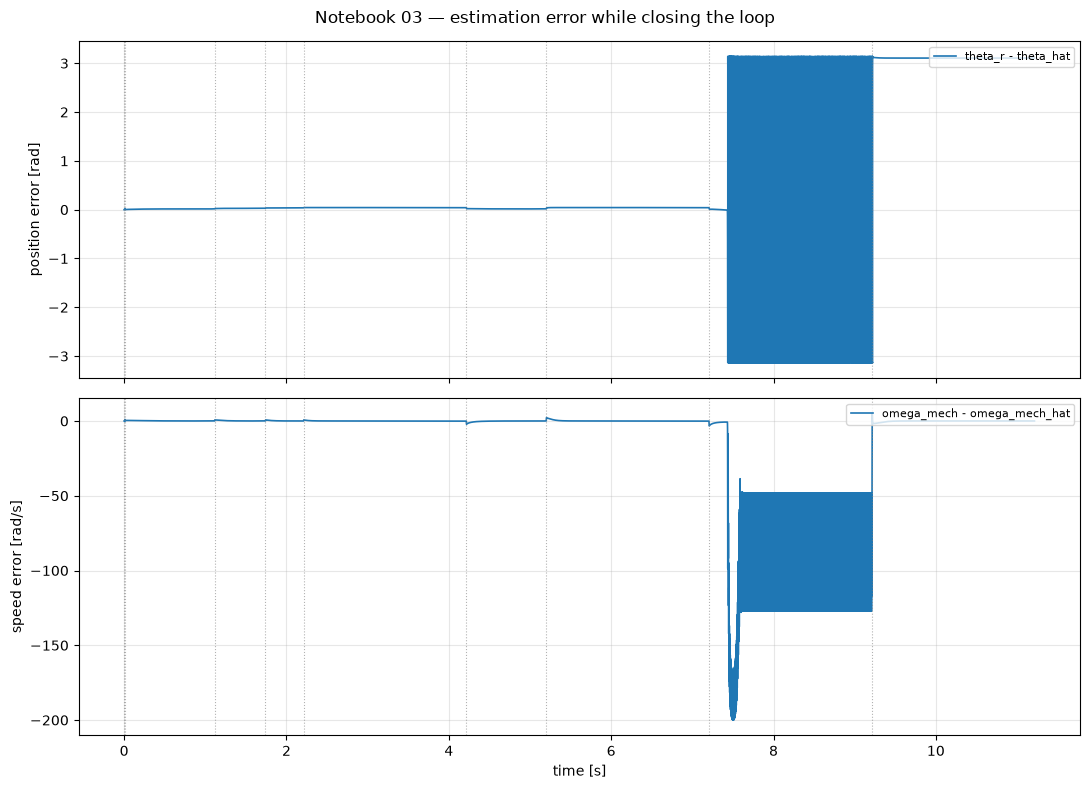

In [5]:
theta_err = pc.wrap_to_pi(theta_r - theta_pll)
omega_mech_hat = omega_pll / p.p
omega_err = omega_mech - omega_mech_hat

fig, axes = pc.plot_traces(
    t,
    {
        "position error [rad]": [("theta_r - theta_hat", theta_err)],
        "speed error [rad/s]": [("omega_mech - omega_mech_hat", omega_err)],
    },
    level_times=level_times,
    title="Notebook 03 — estimation error while closing the loop",
)

# voltage saturation check (fully vectorized -- X has ~10^6 columns, no per-sample Python loop)
xi_d, xi_q = X[4], X[5]
i_alpha, i_beta = pc.dq_to_alphabeta(isd, isq, theta_r)
isd_hat, isq_hat = pc.alphabeta_to_dq(i_alpha, i_beta, theta_pll)
err_d = 0.0 - isd_hat                    # isd_ref = 0 throughout (id*=0 strategy)
err_q = iq_ref_t - isq_hat
ff_d = -omega_pll * p.Lq * isq_hat
ff_q = omega_pll * p.Ld * isd_hat + omega_pll * p.psi_m_pi
usd_unsat = p.Kp_d * err_d + xi_d + ff_d
usq_unsat = p.Kp_q * err_q + xi_q + ff_q
mag = np.hypot(usd_unsat, usq_unsat)
frac_sat = np.mean(mag > p.Vmax)
print(f"unsaturated command magnitude: max={mag.max():.1f} V, Vmax={p.Vmax} V, "
      f"fraction of samples saturated={frac_sat:.4%}")

## Discussion — what actually happened

- On the positive-torque levels (10/30/50/70 N·m, first pass), the drive behaves close to
  notebook 01/02's real-feedback case — small residual current ripple from the observer
  coupling (a few tenths of a %, consistent with notebook 02's documented bias) occasionally
  keeps the strict `iq_tol=0.05 A` convergence check from latching for the full `n_confirm`
  streak within the 2 s budget (see the two "did not converge" warnings at `Tref=70`), but the
  `Te`/speed traces are visually flat and correct — a genuinely converged, working
  torque control, just short of the tolerance's strict letter.
- On the `-20` N·m level, the θ+π lock identified in notebook 02 turns into a **sustained
  oscillation**, not a quiet mistracking: `Te` swings roughly **±20 N·m** and the *estimated*
  speed swings by roughly a thousand rpm — because the controller's estimated currents come
  out essentially negated relative to the real ones (`Park(θ̂)` at `θ̂≈θr+π` flips both axes),
  so it chases the wrong sign of error and the loop never settles while `θ̂` and `θr` keep
  fighting over which branch is "true". This did not converge within the 2 s / 90 s wall-clock
  budget — it is chaotic, not merely slow. (With the PLL bandwidth as originally over-tuned —
  see `THEORY.md` §5.4 — this same oscillation was over 10x more violent, `Te` swinging to
  ~±220 N·m; the retuned PLL doesn't change *whether* the drive loses control here, only how
  hard it thrashes while it does.)
- **The most important finding: the drive does not recover once the reversal ends.** The final
  `50` N·m level settles — cleanly, with near-zero speed error — into `θ̂ = θr+π` *permanently*.
  This is a genuine, self-consistent equilibrium of the closed loop, not a lingering transient:
  with the frame flipped, the controller's estimated `iq` is `-iq_real`, so driving *that*
  toward `+iq_ref` drives the real `iq` toward `-iq_ref` — i.e. a commanded **+50 N·m** produces
  a settled response that looks like a **-50 N·m** command was given (`Te≈-50` N·m, `n_hat`
  tracks `n_mech` accurately in *rate*, just phase-shifted by π — see the flat `+π`
  position-error / near-zero speed-error plot above). Nothing in the rest of the schedule
  can dislodge it. Real drives resolve this with an independent sign-of-speed reference or a
  re-synchronization procedure — out of scope here, so the loop is simply left to show what it
  actually does.
- This is the sensorless drive's own concrete version of the source paper's low/zero-speed weak
  point (`THEORY.md` §7.1, citing Urbanski 2015 §5): a pure back-EMF-angle observer, with no
  independent sign-of-speed reference, cannot reliably run this drive through a speed reversal
  — and once it mis-locks, nothing in a normal operating schedule fixes it. Documented here,
  not engineered around.
- Compare the `converged_flags` above with notebook 01/02's (all `True`) to see this land
  concretely, and compare the estimation-error plot against notebook 02's passive-observer case
  (there, the same π flip appeared but never got to affect the real plant).

## Summary across the three notebooks

| | 01 (real fb.) | 02 (parallel obs.) | 03 (sensorless) |
|---|---|---|---|
| Controller feedback | real θr, ωmech | real θr, ωmech | **θ̂, ω̂** |
| Observer | — | passive, monitored only | **closes the loop** |
| Positive-torque levels | clean step response | clean (+ small obs. bias) | close to 01/02, small extra ripple |
| `-20` N·m (reversal) | clean settle to ω≈-84 rad/s | clean plant, but θ̂ locks θr+π | **chaotic**: Te swings ~±20 N·m |
| Level *after* the reversal (`+50` N·m) | clean settle to ω≈+133 rad/s | clean, θ̂ re-acquires θr | **stuck at θ̂=θr+π** — settles to `Te≈-50` N·m instead |

This is the intended end state of the staged build described in `THEORY.md`: each notebook
adds exactly one piece (plant+control → +observer → observer-closes-the-loop), so the specific
cost of going sensorless — invisible in notebook 02, where the same π flip occurs but only
ever gets *watched*, and fully consequential only once notebook 03 actually trusts the
estimate — is isolated and attributable rather than tangled up with everything else.